# AN EMPIRICAL EVALUATION OF MACHINE LEARNING MODELS FOR USED CAR PRICE PREDICTION



This project aims to predict used car prices using supervised machine learning techniques. The dataset used in this study is publicly available on kaggle, an open online platform for data science and machine learning practitioners. The dataset contains 6,019 instances(rows) and 14 features (columns) describing vehicle specifications.
we will be exploring and evaluating Ridge regression, Random forest,and XGBoost.


To start, i will begin with the data cleaning and preprocessing.


## Import Useful Libraries




In [5]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sklearn preprocessing & pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Sklearn models & metrics
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


# Explainability
import shap
from shap import LinearExplainer


print("All libraries imported successfully.")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully.
XGBoost version: 3.2.0


## Load Dataset

To load the data set we first import and mount drive because the dataset is stored in google drive.

In [6]:
# Mount google drive.
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# load dataset
# path = ('/content/drive/MyDrive/Colab Notebooks/train-data.csv') i was using the dataset from my drive.

data = pd.read_csv('/content/train-data.csv') #add path or dataset name to read csv file.

# create DataFrame.

df = pd.DataFrame(data)

### Data Structure & Statistical Overview

Inspect the dataset dimensions, data types, and descriptive statistics to understand its structure before any cleaning.

In [8]:
print("-- Dataset Shape ---")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n--- Column Types ---")
df.info()

-- Dataset Shape ---
Rows: 6,019  |  Columns: 14

--- Column Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 

In [9]:
# Statistical summary of numerical columns
df.describe().round(2)

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,6019.00,6019.00,6019.00,5977.00,6019.00
mean,3009.00,2013.36,58738.38,5.28,9.48
std,1737.68,3.27,91268.84,0.81,11.19
min,0.00,1998.00,171.00,0.00,0.44
25%,1504.50,2011.00,34000.00,5.00,3.50
50%,3009.00,2014.00,53000.00,5.00,5.64
75%,4513.50,2016.00,73000.00,5.00,9.95
max,6018.00,2019.00,6500000.00,10.00,160.00


## Duplicate Detection

In [10]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


## Missing Value Analysis

In [11]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing Count'] > 0])

           Missing Count  Missing %
New_Price           5195      86.31
Seats                 42       0.70
Power                 36       0.60
Engine                36       0.60
Mileage                2       0.03


Understanding missingness is critical before imputation decisions.


From the above we can see that the `New_Price` column has approximately 86% missing values and will be dropped entirely.

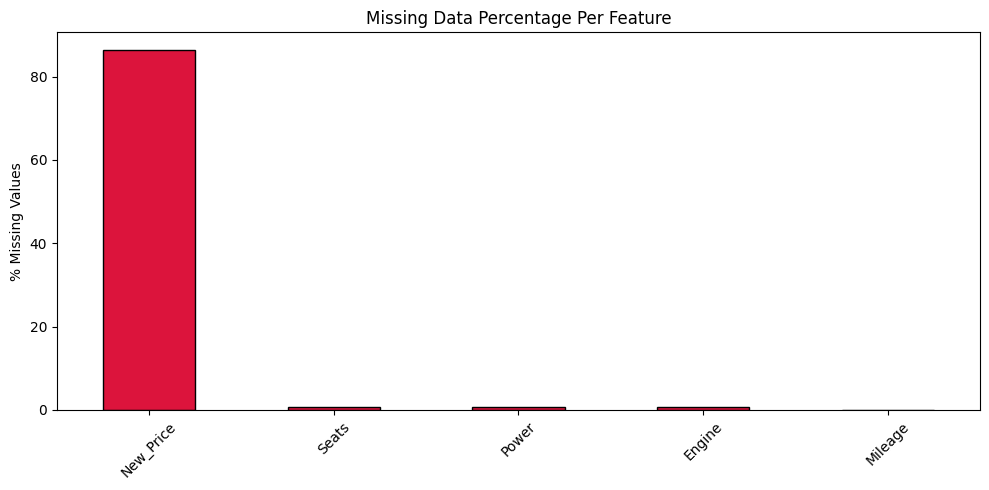

In [12]:
# Visualise missing data
plt.figure(figsize=(10, 5))
missing_pct = df.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values(ascending=False).plot.bar(color='crimson', edgecolor='black')
plt.ylabel("% Missing Values")
plt.title("Missing Data Percentage Per Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Preparation & Cleaning

`New_Price` (>86% missing) and `Unnamed: 0` (row index) are removed as they carry no predictive value.  
String numeric features (`Mileage`, `Engine`, `Power`) are parsed to floats.

In [13]:
# Drop uninformative columns
df.drop(columns=['Unnamed: 0', 'New_Price'], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']


In [14]:
# Extract brand name (first word) and fix 'Land Rover' two-word brand
df['Name'] = df['Name'].str.split().str[0].replace('Land', 'Land Rover')
print("Top 10 brands:")
print(df['Name'].value_counts().head(10))

Top 10 brands:
Name
Maruti           1211
Hyundai          1107
Honda             608
Toyota            411
Mercedes-Benz     318
Volkswagen        315
Ford              300
Mahindra          272
BMW               267
Audi              236
Name: count, dtype: int64


In [15]:
# handle numeric, string, and "null bhp" mixed columns

for col in ['Mileage', 'Engine', 'Power']:
    if df[col].dtype == object:
      # strip "null" and extract numeric part
        df[col] = (df[col]
                   .str.replace('null', '', regex=False)
                   .str.strip()
                   .str.split()
                   .str[0])
    # Convert everything to float, coercing any remaining bad values to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rename columns to reflect units
df.rename(columns={
    'Mileage': 'Mileage_(kmpl)',
    'Engine':  'Engine_(cc)',
    'Power':   'Power_(bhp)',
    'Price':   'Price_(lakh)'
}, inplace=True)

print("Cleaned columns:", df.columns.tolist())



Cleaned columns: ['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage_(kmpl)', 'Engine_(cc)', 'Power_(bhp)', 'Seats', 'Price_(lakh)']


In [16]:
#check for missing values after cleaning

print("\nMissing values after parsing:")
print(df[['Mileage_(kmpl)', 'Engine_(cc)', 'Power_(bhp)']].isnull().sum())



Missing values after parsing:
Mileage_(kmpl)      2
Engine_(cc)        36
Power_(bhp)       143
dtype: int64


For columns with <1% missing values (`Engine`, `Power`, `Mileage`, `Seats`) we apply **median imputation**.  
Median is preferred over mean for right-skewed distributions as it is robust to outliers.

In [17]:
# Median imputation for numerical columns
for col in ['Engine_(cc)', 'Power_(bhp)', 'Mileage_(kmpl)', 'Seats']:
    df[col] = df[col].fillna(df[col].median())

# Confirm zero missing values remain
print("Missing values post-imputation:", df.isnull().sum().sum())
df.info()

Missing values post-imputation: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage_(kmpl)     6019 non-null   float64
 8   Engine_(cc)        6019 non-null   float64
 9   Power_(bhp)        6019 non-null   float64
 10  Seats              6019 non-null   float64
 11  Price_(lakh)       6019 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 564.4+ KB


## Exploratory Data Analysis (EDA)

Categorical columns: ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']


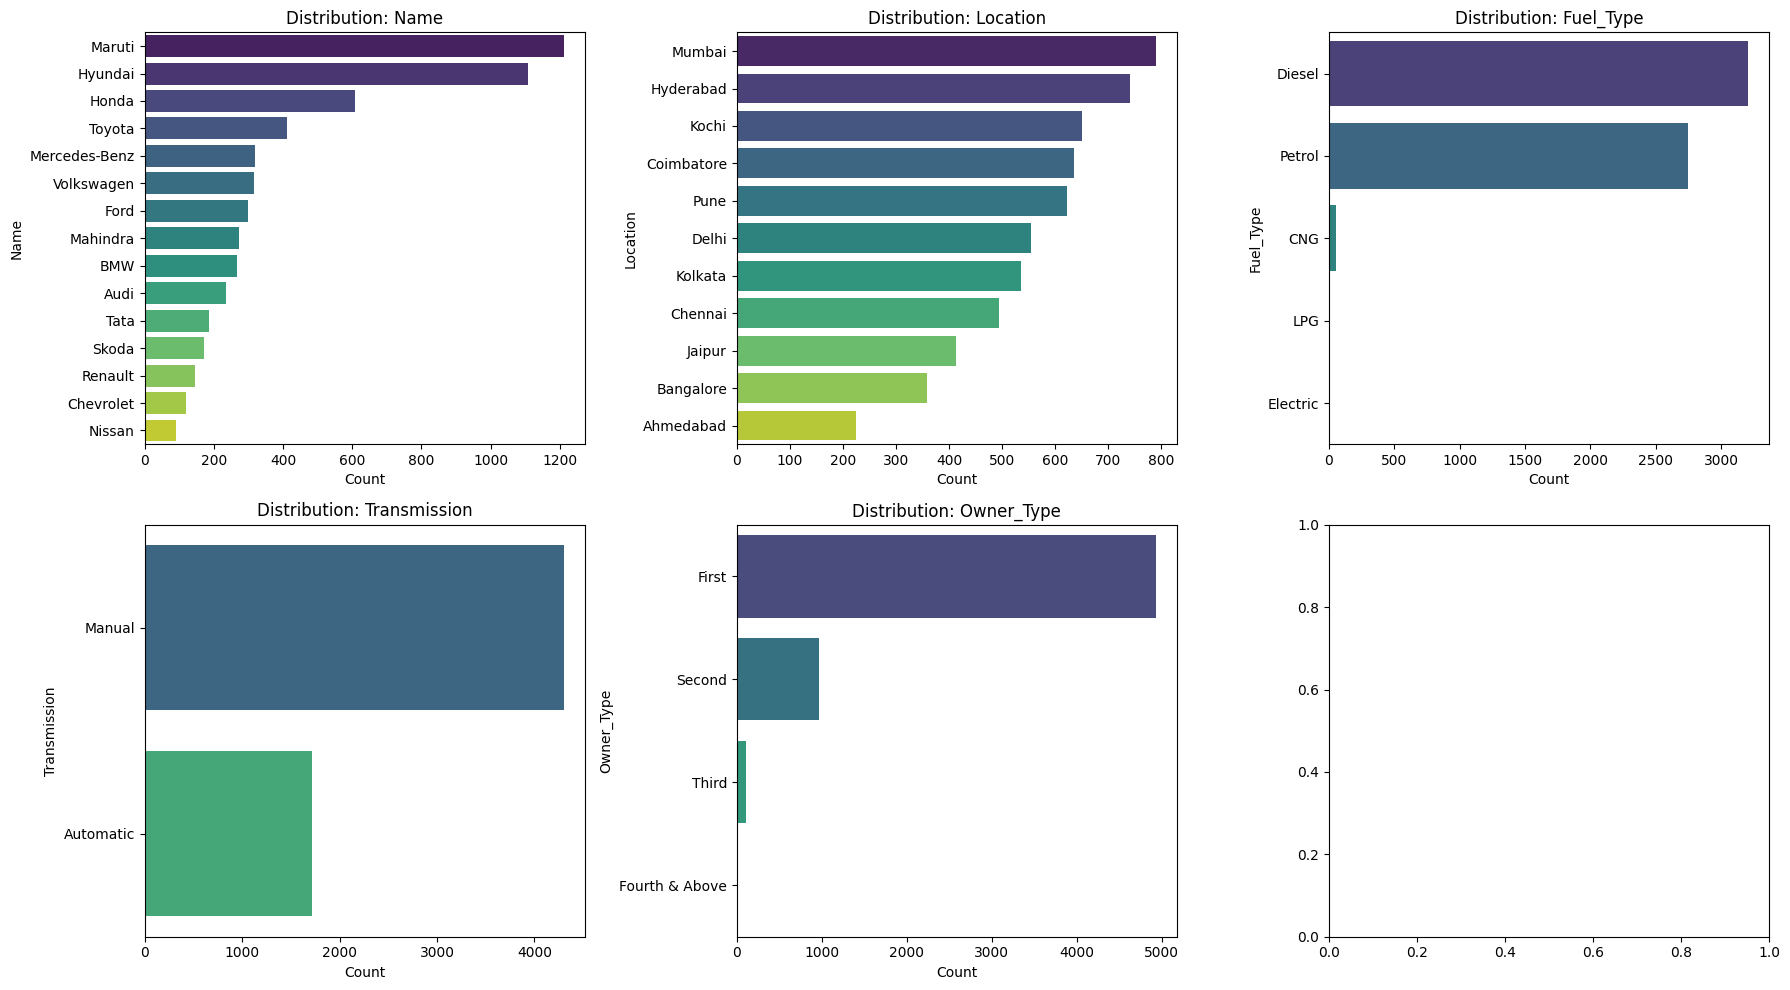

In [18]:
#Categorical Feature Distributions

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(15)
    sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Outlier Detection: Univariate Box Plots

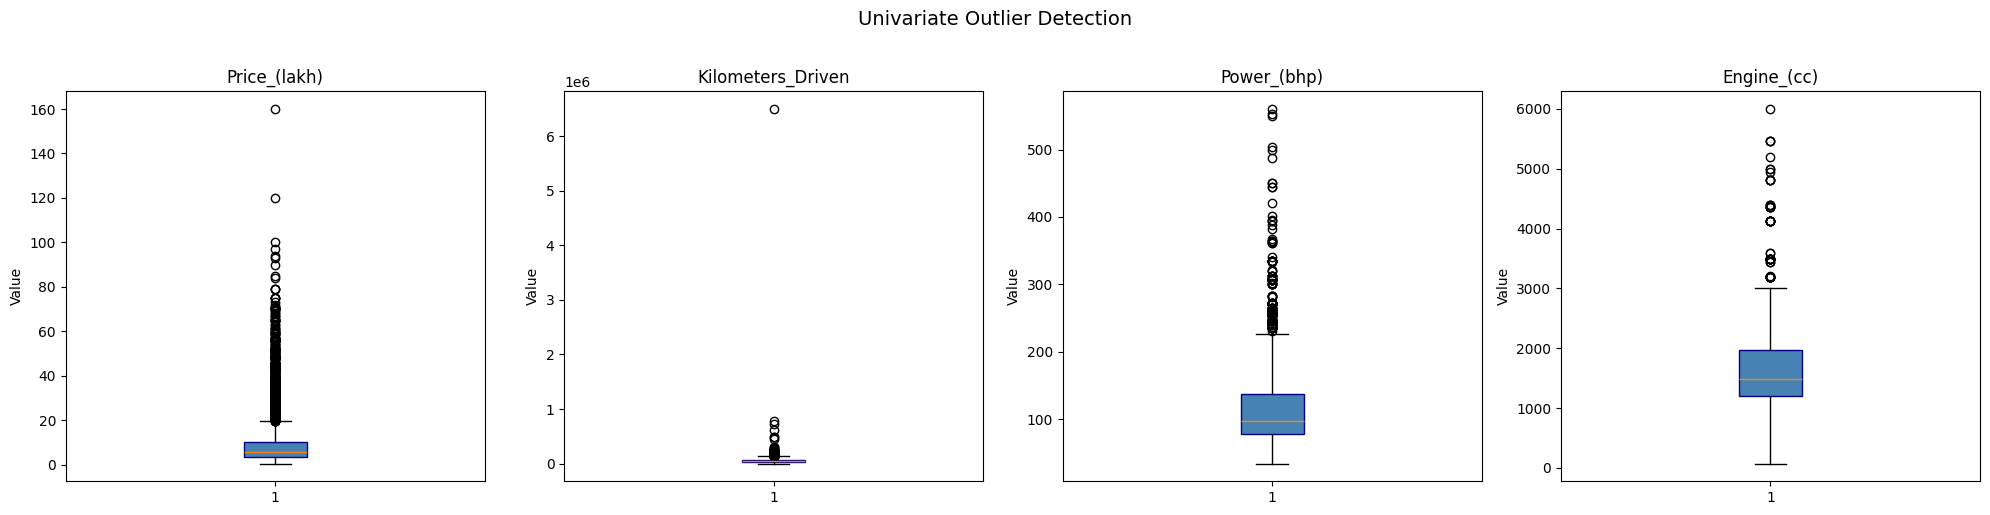

,Price_(lakh),Kilometers_Driven,Power_(bhp),Engine_(cc)
count,6019.00,6019.00,6019.00,6019.00
mean,9.48,58738.38,112.88,1620.51
std,11.19,91268.84,53.28,599.64
min,0.44,171.00,34.20,72.00
25%,3.50,34000.00,78.00,1198.00
50%,5.64,53000.00,97.70,1493.00
75%,9.95,73000.00,138.03,1969.00
max,160.00,6500000.00,560.00,5998.00


In [19]:
cols_to_check = ['Price_(lakh)', 'Kilometers_Driven', 'Power_(bhp)', 'Engine_(cc)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, cols_to_check):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy'))
    ax.set_title(col)
    ax.set_ylabel('Value')
plt.suptitle('Univariate Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Statistical summary
df[cols_to_check].describe().round(2)

Extreme outliers in `Kilometers_Driven` and `Price_(lakh)` are visible.  
These can distort model training and must be identified and handled.

In [20]:
# Identify extreme Kilometers_Driven outlier
print("Top 5 highest mileage cars:")
display(df.nlargest(5, 'Kilometers_Driven')[['Name', 'Year', 'Kilometers_Driven', 'Price_(lakh)']])

Top 5 highest mileage cars:


,Name,Year,Kilometers_Driven,Price_(lakh)
2328,BMW,2017,6500000,65.0
340,Skoda,2013,775000,7.5
1860,Volkswagen,2013,720000,5.9
358,Hyundai,2009,620000,2.7
2823,Volkswagen,2015,480000,13.0


The 2017 BMW with 6,500,000 km is a clear data entry error  ~2,000 km/day would be physically impossible.  
This single point causes an extreme influential outlier and is removed.

In [21]:
# Remove the impossible outlier row
outlier_idx = df['Kilometers_Driven'].idxmax()
df = df.drop(index=outlier_idx)
print(f"Removed index {outlier_idx}. Max Km_Driven now: {df['Kilometers_Driven'].max():,}")

Removed index 2328. Max Km_Driven now: 775,000


### Target Variable Distribution

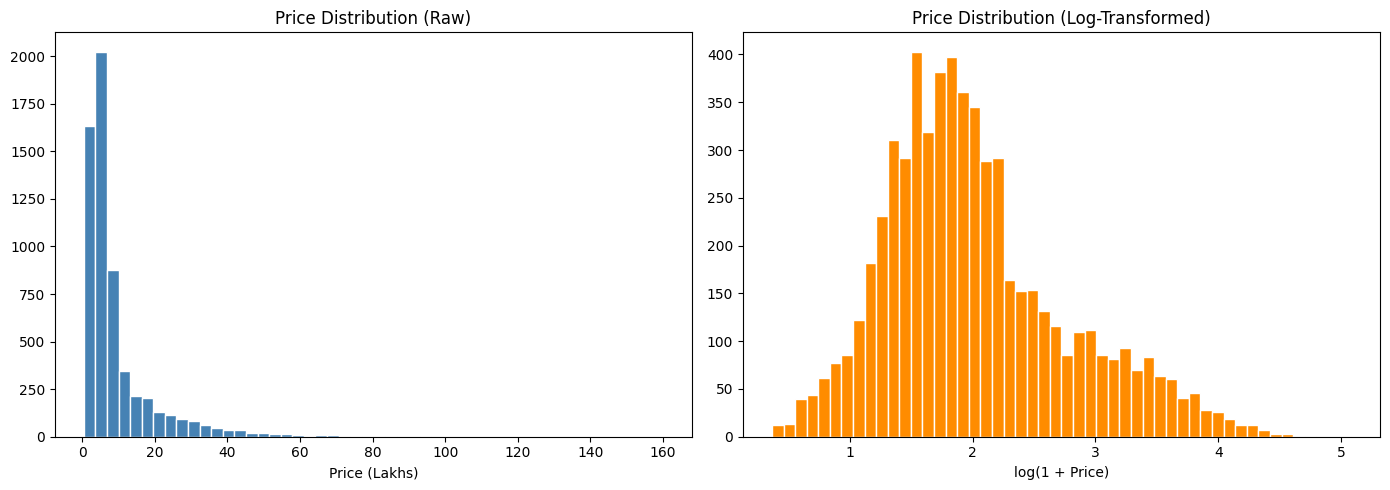

Skewness Raw: 3.34  |  Log-transformed: 0.75


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price_(lakh)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (Lakhs)')

axes[1].hist(np.log1p(df['Price_(lakh)']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()


skew_raw = stats.skew(df['Price_(lakh)'])
skew_log  = stats.skew(np.log1p(df['Price_(lakh)']))
print(f"Skewness Raw: {skew_raw:.2f}  |  Log-transformed: {skew_log:.2f}")

### Bivariate Analysis

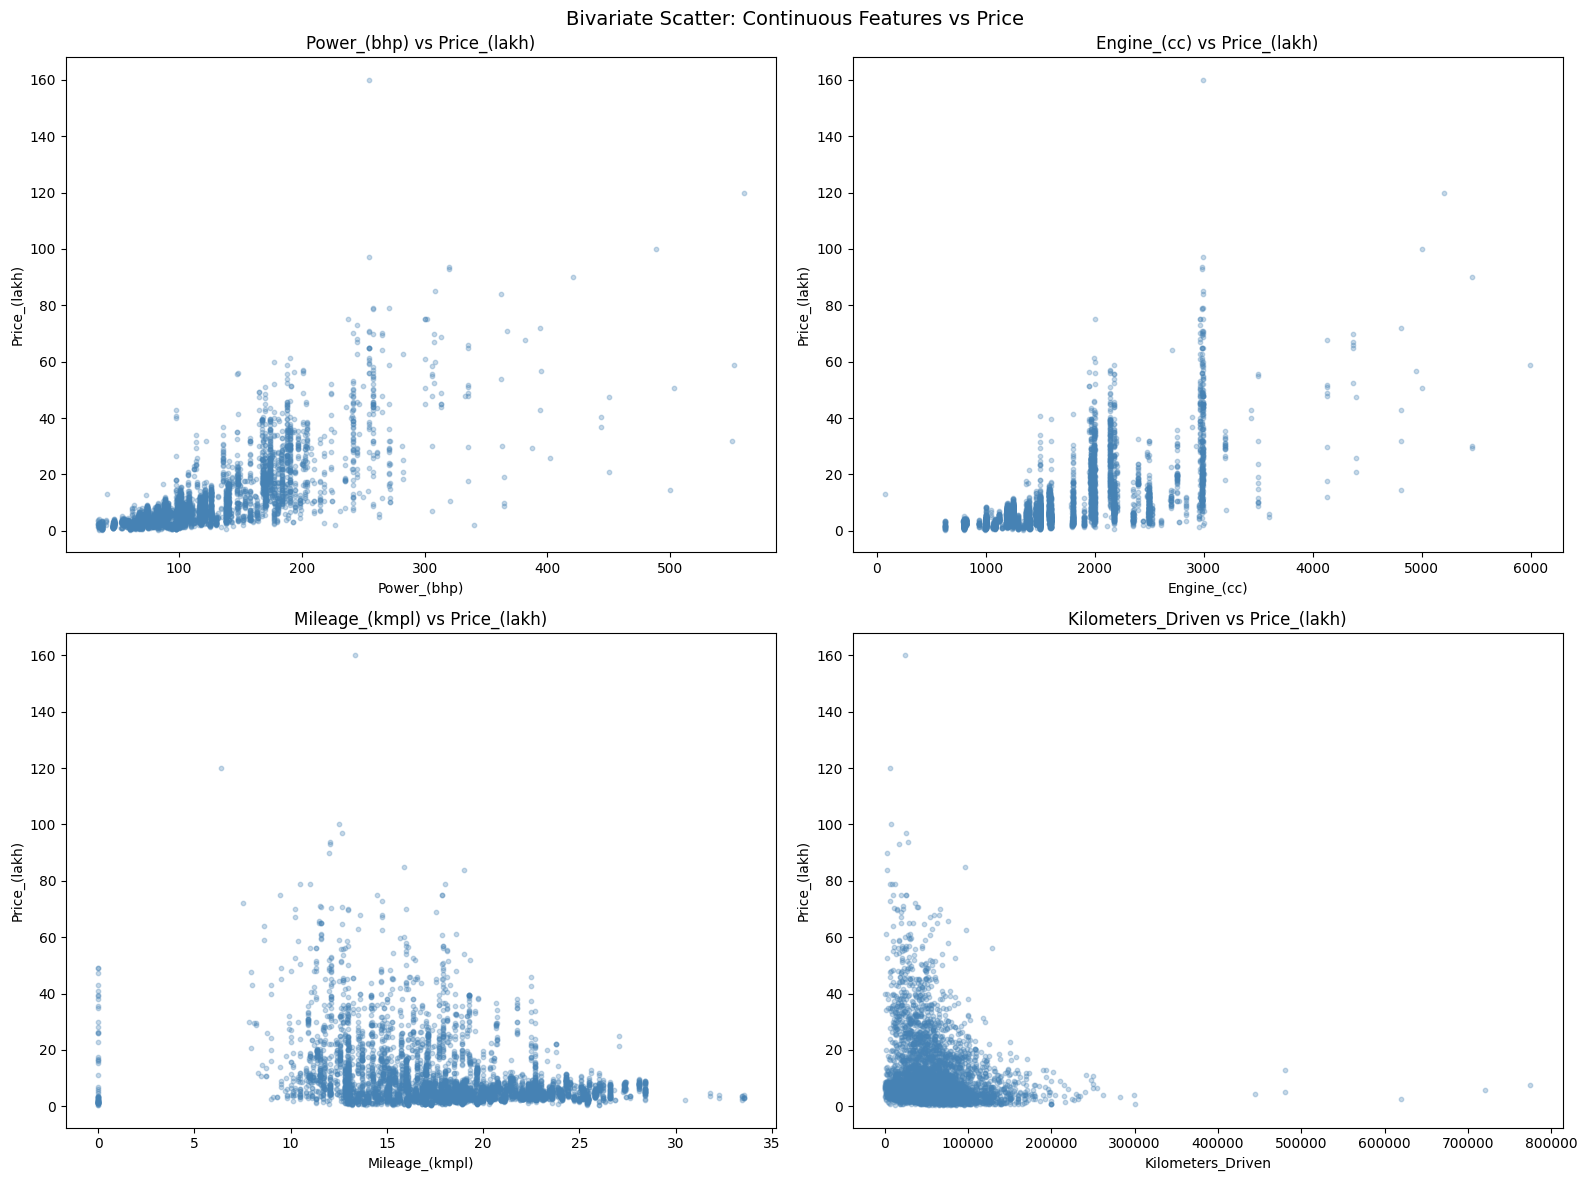

In [23]:
#Continuous Features vs Price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pairs = [('Power_(bhp)', 'Price_(lakh)'), ('Engine_(cc)', 'Price_(lakh)'),
         ('Mileage_(kmpl)', 'Price_(lakh)'), ('Kilometers_Driven', 'Price_(lakh)')]

for ax, (x, y) in zip(axes.flatten(), pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
plt.suptitle('Bivariate Scatter: Continuous Features vs Price', fontsize=14)
plt.tight_layout()
plt.show()

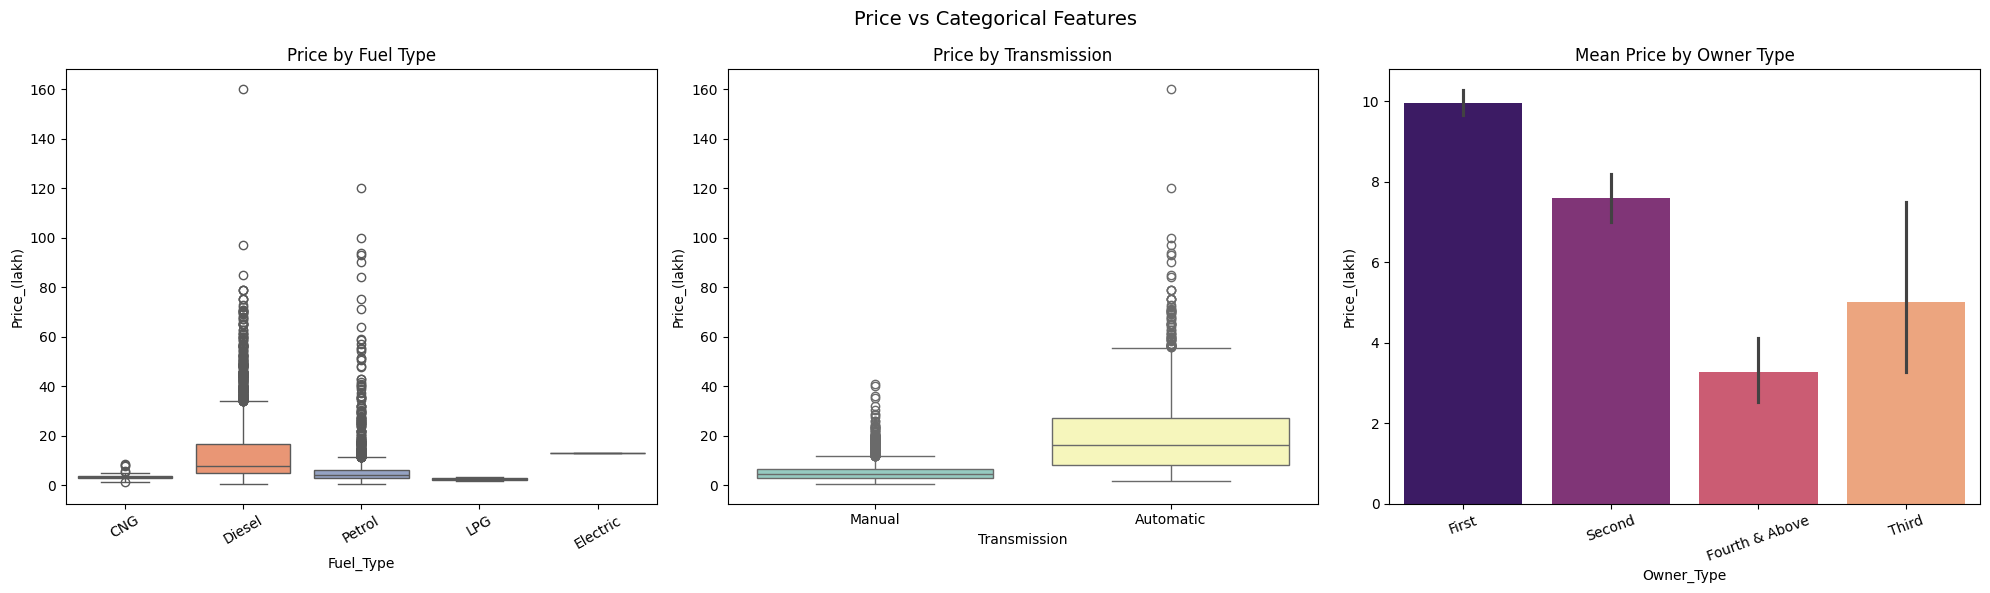

In [24]:
# Categorical Features vs Price

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='Fuel_Type',    y='Price_(lakh)', ax=axes[0], palette='Set2')
axes[0].set_title('Price by Fuel Type'); axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Transmission', y='Price_(lakh)', ax=axes[1], palette='Set3')
axes[1].set_title('Price by Transmission')

sns.barplot(data=df, x='Owner_Type',   y='Price_(lakh)', estimator='mean',
            ax=axes[2], palette='magma')
axes[2].set_title('Mean Price by Owner Type'); axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Price vs Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Multivariate: Correlation Heatmap

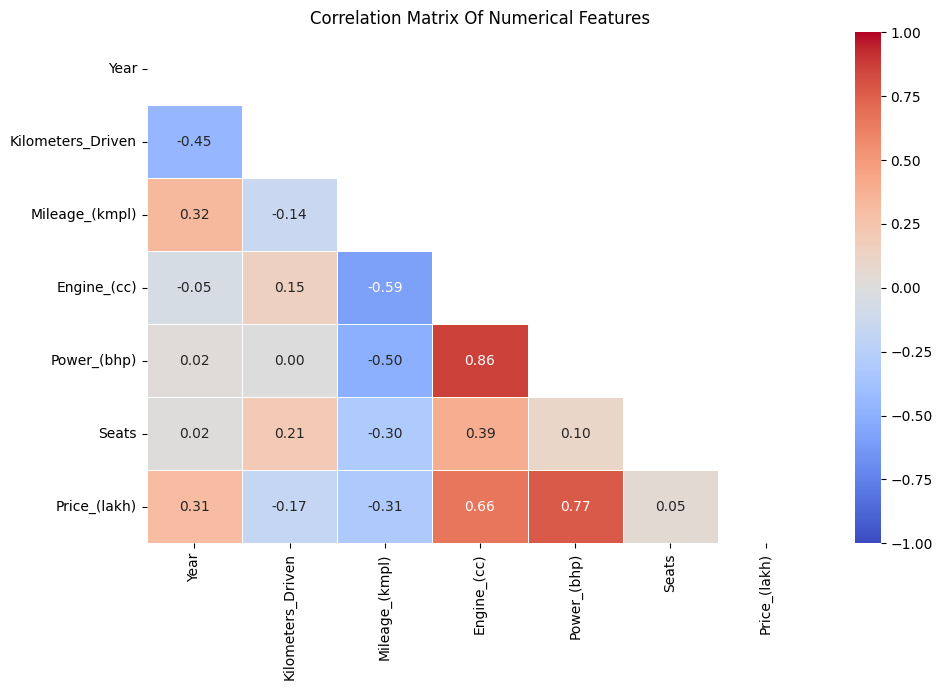

In [25]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Of Numerical Features')
plt.tight_layout()
plt.show()

In [26]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage_(kmpl),Engine_(cc),Power_(bhp),Seats,Price_(lakh)
0,Maruti,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


### Price Interaction: Fuel Type × Transmission

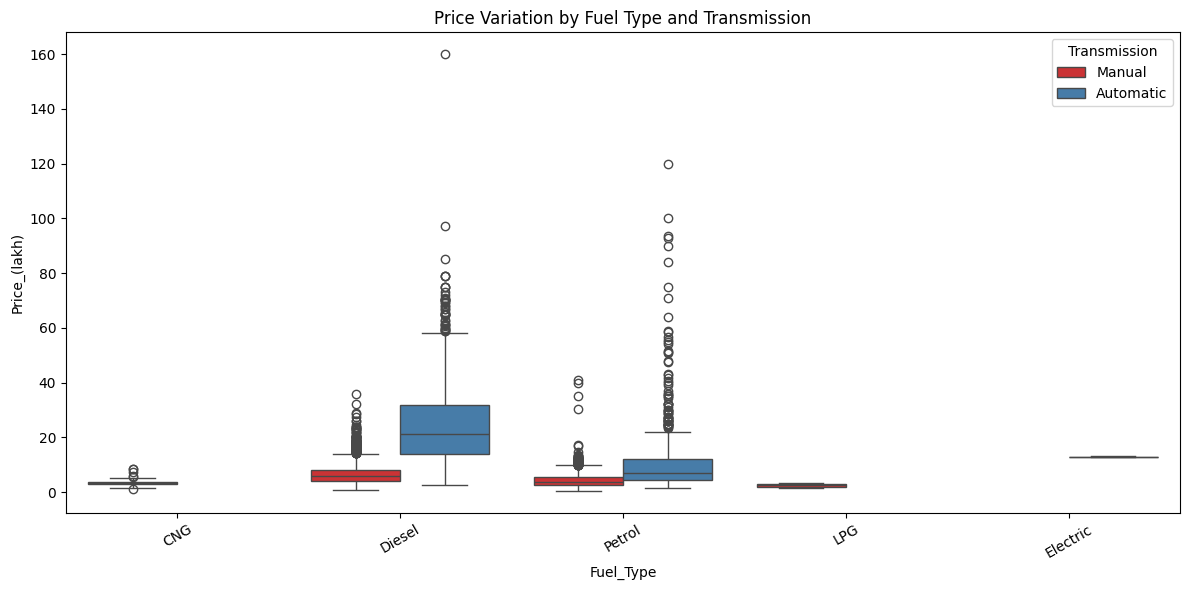

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Fuel_Type', y='Price_(lakh)', hue='Transmission', palette='Set1')
plt.title('Price Variation by Fuel Type and Transmission')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Feature Engineering

We will apply two transformations:
1. **Car Age** (`Age = 2026 − Year`): directly represents depreciation rather than a raw year, which is more informative for the model.
2. **Log-transformation** of `Kilometers_Driven` and `Price_(lakh)` to reduce right-skewness and compress extreme values, improving linear model assumptions.

In [28]:
# Age feature (as of 2026)
df['Age'] = 2026 - df['Year']
df.drop(columns='Year', inplace=True)

# Log-transform skewed features
df['Price_log'] = np.log1p(df['Price_(lakh)'])
df['Km_log']    = np.log1p(df['Kilometers_Driven'])

# Drop original skewed columns
df.drop(columns=['Price_(lakh)', 'Kilometers_Driven'], inplace=True)

print("Final feature set:")
print(df.columns.tolist())
df.head(3)

Final feature set:
['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage_(kmpl)', 'Engine_(cc)', 'Power_(bhp)', 'Seats', 'Age', 'Price_log', 'Km_log']


,Name,Location,Fuel_Type,Transmission,Owner_Type,Mileage_(kmpl),Engine_(cc),Power_(bhp),Seats,Age,Price_log,Km_log
0,Maruti,Mumbai,CNG,Manual,First,26.60,998.0,58.16,5.0,16,1.011601,11.184435
1,Hyundai,Pune,Diesel,Manual,First,19.67,1582.0,126.20,5.0,11,2.602690,10.621352
2,Honda,Chennai,Petrol,Manual,First,18.20,1199.0,88.70,5.0,15,1.704748,10.736418


In [29]:
df['Location'].value_counts()

,count
Location,
Mumbai,790
Hyderabad,742
Kochi,651
Coimbatore,636
Pune,622
Delhi,554
Kolkata,535
Chennai,493
Jaipur,413


## Feature/Target Split & Train-Test Split

In [30]:
X = df.drop(columns='Price_log')
y = df['Price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 4,814
Testing samples  : 1,204
Features         : 11


## Preprocessing Pipeline

We will use a `ColumnTransformer` to encapsulate preprocessing for numerical and categorical features separately.
Wrapping preprocessing in a sklearn `Pipeline` prevents **data leakage**: all transformations are fitted only on training data and applied to test data.

In [31]:
numeric_cols     = ['Mileage_(kmpl)', 'Engine_(cc)', 'Power_(bhp)', 'Seats', 'Age', 'Km_log']
categorical_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Name']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


 **Ridge Regression**

Ridge regression extends Ordinary Least Squares with L2 regularisation (penalty on coefficient magnitude), which reduces overfitting when features are correlated. Overfitting might be a common issue in this dataset given the high correlation between `Engine_(cc)` and `Power_(bhp)` (r = 0.85).  
This will serve as the **interpretable linear baseline** against which ensemble models will be compared.

In [32]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Mileage_(kmpl)',
                                                   'Engine_(cc)', 'Power_(bhp)',
                                                   'Seats', 'Age', 'Km_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Location', 'Fuel_Type',
                                                   'Transmission', 'Owner_Type',
                                                   'Name'])])),
                ('regressor', Ridge())])

In [33]:
# Predictions ( revert log scale for interpretable metrics)
y_pred_log_ridge    = ridge_pipeline.predict(X_test)
y_pred_actual_ridge = np.expm1(y_pred_log_ridge)
y_test_actual       = np.expm1(y_test)

r2_ridge   = r2_score(y_test, y_pred_log_ridge)
mae_ridge  = mean_absolute_error(y_test_actual, y_pred_actual_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_actual, y_pred_actual_ridge) * 100
rmse_ridge = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_ridge))

# 5-fold cross-validation
cv_ridge = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')

print("--- Ridge Regression ---")
print(f"R²   (test)      : {r2_ridge:.4f}")
print(f"MAE  (test)      : {mae_ridge:.2f} Lakhs")
print(f"MAPE (test)      : {mape_ridge:.2f}%")
print(f"RMSE (test)      : {rmse_ridge:.2f} Lakhs")
print(f"CV R² (5-fold)   : {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}")

--- Ridge Regression ---
R²   (test)      : 0.9224
MAE  (test)      : 1.76 Lakhs
MAPE (test)      : 19.66%
RMSE (test)      : 4.56 Lakhs
CV R² (5-fold)   : 0.9229 ± 0.0110


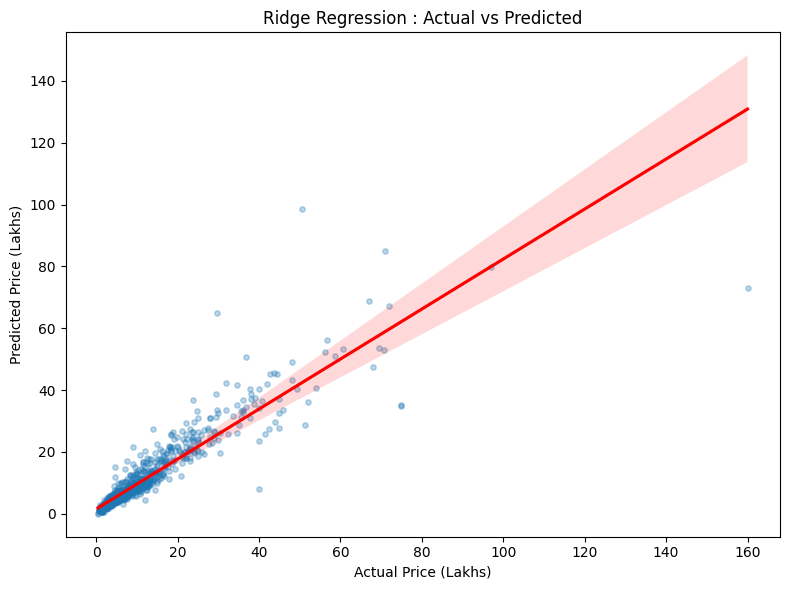

In [34]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test_actual, y=y_pred_actual_ridge,
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.xlabel('Actual Price (Lakhs)'); plt.ylabel('Predicted Price (Lakhs)')
plt.title('Ridge Regression : Actual vs Predicted')
plt.tight_layout()
plt.show()

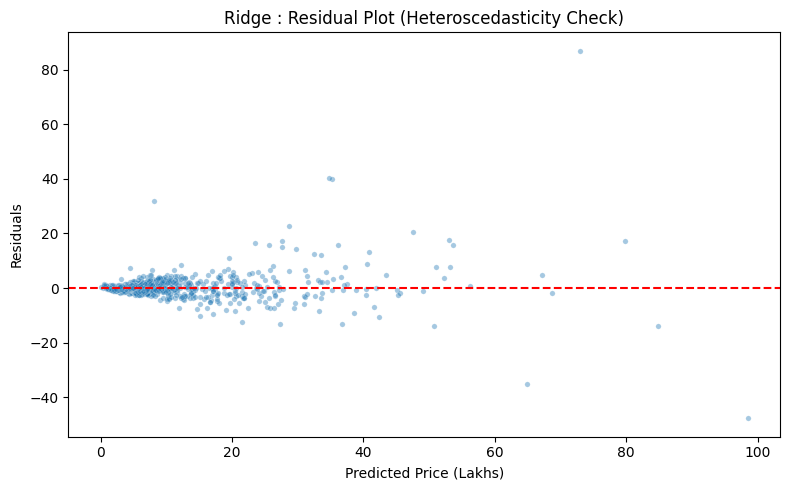

In [35]:
# Residual plot
residuals_ridge = y_test_actual - y_pred_actual_ridge
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_actual_ridge, y=residuals_ridge, alpha=0.4, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (Lakhs)'); plt.ylabel('Residuals')
plt.title('Ridge : Residual Plot (Heteroscedasticity Check)')
plt.tight_layout()
plt.show()

  From the ridge regression plot above we can observe that the funnel-shaped residual pattern indicates **heteroscedasticity**. The variance of errors increases with predicted price. This is expected with linear models on skewed data. Ensemble models should reduce this effect.

## Model 2: Random Forest Regressor (Ensemble)

Random Forest builds many decision trees on bootstrapped subsets of training data and averages their predictions.


This is the first step beyond linearity in our model comparison.

In [36]:
#Random forest pipeline

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

y_pred_log_rf    = rf_pipeline.predict(X_test)
y_pred_actual_rf = np.expm1(y_pred_log_rf)

r2_rf   = r2_score(y_test, y_pred_log_rf)
mae_rf  = mean_absolute_error(y_test_actual, y_pred_actual_rf)
mape_rf = mean_absolute_percentage_error(y_test_actual, y_pred_actual_rf) * 100
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_rf))

cv_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("--- Random Forest ---")
print(f"R²   (test)      : {r2_rf:.4f}")
print(f"MAE  (test)      : {mae_rf:.2f} Lakhs")
print(f"MAPE (test)      : {mape_rf:.2f}%")
print(f"RMSE (test)      : {rmse_rf:.2f} Lakhs")
print(f"CV R² (5-fold)   : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

--- Random Forest ---
R²   (test)      : 0.9407
MAE  (test)      : 1.55 Lakhs
MAPE (test)      : 15.84%
RMSE (test)      : 4.87 Lakhs
CV R² (5-fold)   : 0.9361 ± 0.0141


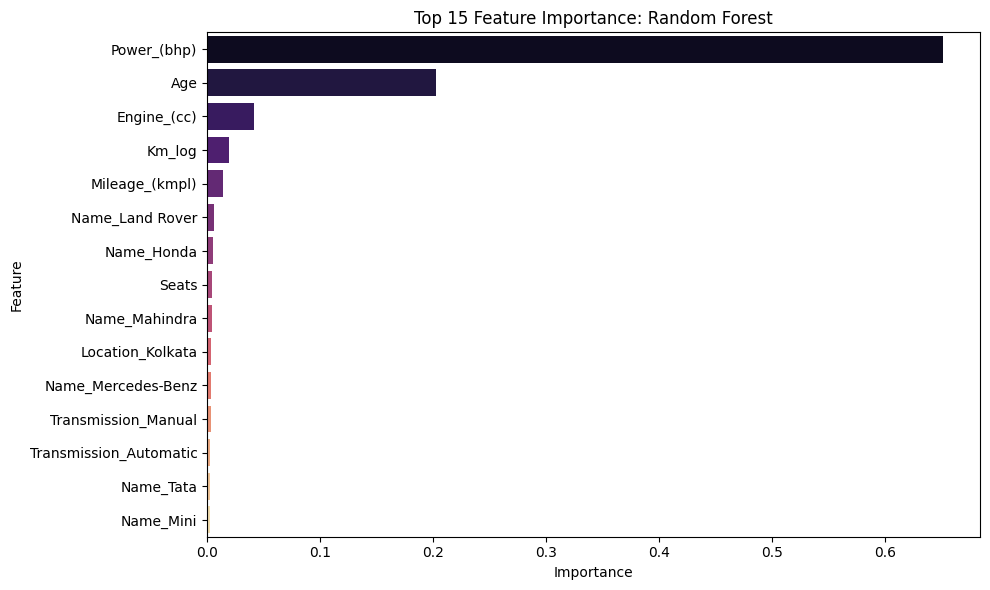

In [37]:
# RF Feature Importance
cat_features_rf = (rf_pipeline.named_steps['preprocessor']
                   .transformers_[1][1]
                   .get_feature_names_out(categorical_cols))
all_features_rf = numeric_cols + list(cat_features_rf)

importances_rf = rf_pipeline.named_steps['regressor'].feature_importances_
feat_df_rf = (pd.DataFrame({'Feature': all_features_rf, 'Importance': importances_rf})
              .sort_values('Importance', ascending=False)
              .head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df_rf, palette='magma')
plt.title('Top 15 Feature Importance: Random Forest')
plt.tight_layout()
plt.show()

 **XGBoost Regressor**

XGBoost uses **gradient boosting**: trees are built sequentially, each correcting the errors of the previous one. It incorporates regularisation (L1/L2), handles missing values natively, and consistently outperforms Random Forest on tabular data.
This is our primary candidate for best performance.

In [38]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        random_state=42, n_jobs=-1, verbosity=0
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_log_xgb    = xgb_pipeline.predict(X_test)
y_pred_actual_xgb = np.expm1(y_pred_log_xgb)

r2_xgb   = r2_score(y_test, y_pred_log_xgb)
mae_xgb  = mean_absolute_error(y_test_actual, y_pred_actual_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_actual, y_pred_actual_xgb) * 100
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_xgb))

cv_xgb = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("--- XGBoost ---")
print(f"R²   (test)      : {r2_xgb:.4f}")
print(f"MAE  (test)      : {mae_xgb:.2f} Lakhs")
print(f"MAPE (test)      : {mape_xgb:.2f}%")
print(f"RMSE (test)      : {rmse_xgb:.2f} Lakhs")
print(f"CV R² (5-fold)   : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

--- XGBoost ---
R²   (test)      : 0.9462
MAE  (test)      : 1.49 Lakhs
MAPE (test)      : 15.54%
RMSE (test)      : 4.13 Lakhs
CV R² (5-fold)   : 0.9419 ± 0.0123


## Model Comparison

In [39]:
# Comparison table including CV scores

comparison_df = pd.DataFrame([
    {'Model': 'Ridge Regression',
     'R² (test)': round(r2_ridge, 4), 'MAE (lakhs)': round(mae_ridge, 2),
     'RMSE (lakhs)': round(rmse_ridge, 2),
     'MAPE (%)': round(mape_ridge, 2),
     'CV R² Mean': round(cv_ridge.mean(), 4), 'CV R² Std': round(cv_ridge.std(), 4)},
    {'Model': 'Random Forest',
     'R² (test)': round(r2_rf, 4), 'MAE (lakhs)': round(mae_rf, 2),
     'RMSE (lakhs)': round(rmse_rf, 2),
     'MAPE (%)': round(mape_rf, 2),
     'CV R² Mean': round(cv_rf.mean(), 4), 'CV R² Std': round(cv_rf.std(), 4)},
    {'Model': 'XGBoost',
     'R² (test)': round(r2_xgb, 4), 'MAE (lakhs)': round(mae_xgb, 2),
     'RMSE (lakhs)': round(rmse_xgb, 2),
     'MAPE (%)': round(mape_xgb, 2),
     'CV R² Mean': round(cv_xgb.mean(), 4), 'CV R² Std': round(cv_xgb.std(), 4)},
])

print("Table 1: Model Performance Comparison")
display(comparison_df.sort_values('R² (test)', ascending=False).reset_index(drop=True))

Table 1: Model Performance Comparison


,Model,R² (test),MAE (lakhs),RMSE (lakhs),MAPE (%),CV R² Mean,CV R² Std
0,XGBoost,0.9462,1.49,4.13,15.54,0.9419,0.0123
1,Random Forest,0.9407,1.55,4.87,15.84,0.9361,0.0141
2,Ridge Regression,0.9224,1.76,4.56,19.66,0.9229,0.0110


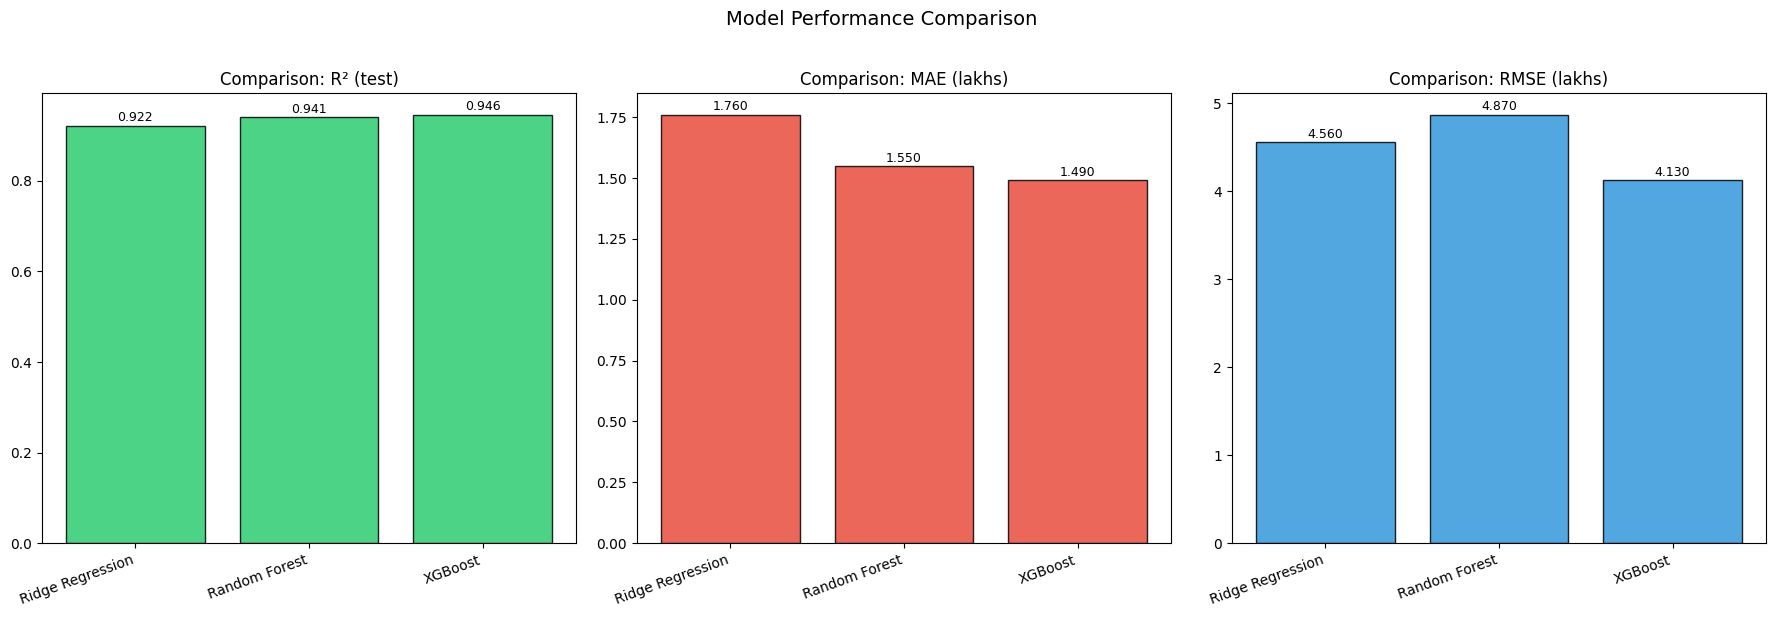

In [40]:
# Side-by-side bar plots for R², MAE, RMSE
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['R² (test)', 'MAE (lakhs)', 'RMSE (lakhs)']
colors  = ['#2ecc71', '#e74c3c', '#3498db']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(comparison_df['Model'], comparison_df[metric], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Comparison: {metric}')
    ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right')
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v + 0.01 * max(comparison_df[metric]), f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Hyperparameter Tunning/Optimisation: Ridge regression

In [41]:
# Grid search over alpha values with 5-fold CV.

ridge_param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_grid_search = GridSearchCV(
    ridge_pipeline, ridge_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
ridge_grid_search.fit(X_train, y_train)

best_ridge = ridge_grid_search.best_estimator_
print(f"\nBest parameters: {ridge_grid_search.best_params_}")
print(f"Best CV R²     : {ridge_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters: {'regressor__alpha': 1.0}
Best CV R²     : 0.9229


# Evaluate Optimized Ridge Regresssion

In [42]:
y_pred_log_ridge_opt    = best_ridge.predict(X_test)
y_pred_actual_ridge_opt = np.expm1(y_pred_log_ridge_opt)

r2_ridge_opt   = r2_score(y_test, y_pred_log_ridge_opt)
mae_ridge_opt  = mean_absolute_error(y_test_actual, y_pred_actual_ridge_opt)
mape_ridge_opt = mean_absolute_percentage_error(y_test_actual, y_pred_actual_ridge_opt) * 100
rmse_ridge_opt = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_ridge_opt))

print("--- Ridge Regression (Optimised) ---")
print(f"R²          : {r2_ridge_opt:.4f}")
print(f"MAE         : {mae_ridge_opt:.2f} Lakhs")
print(f"MAPE (test) : {mape_ridge_opt:.2f}%")
print(f"RMSE        : {rmse_ridge_opt:.2f} Lakhs")

comparison_df.loc[len(comparison_df)] = {
    'Model': 'Ridge Regression (Optimised)', 'R² (test)': round(r2_ridge_opt, 4),
    'MAE (lakhs)': round(mae_ridge_opt, 2), 'MAPE (%)': round(mape_ridge_opt, 2),
    'RMSE (lakhs)': round(rmse_ridge_opt, 2),
    'CV R² Mean': round(ridge_grid_search.best_score_, 4), 'CV R² Std': 0.0
}

print("\nUpdated Model Comparison:")
display(comparison_df.sort_values('R² (test)', ascending=False).reset_index(drop=True))

--- Ridge Regression (Optimised) ---
R²          : 0.9224
MAE         : 1.76 Lakhs
MAPE (test) : 19.66%
RMSE        : 4.56 Lakhs

Updated Model Comparison:


,Model,R² (test),MAE (lakhs),RMSE (lakhs),MAPE (%),CV R² Mean,CV R² Std
0,XGBoost,0.9462,1.49,4.13,15.54,0.9419,0.0123
1,Random Forest,0.9407,1.55,4.87,15.84,0.9361,0.0141
2,Ridge Regression,0.9224,1.76,4.56,19.66,0.9229,0.0110
3,Ridge Regression (Optimised),0.9224,1.76,4.56,19.66,0.9229,0.0000


# FEATURE IMPORTANCE : Optimized Ridege Regression

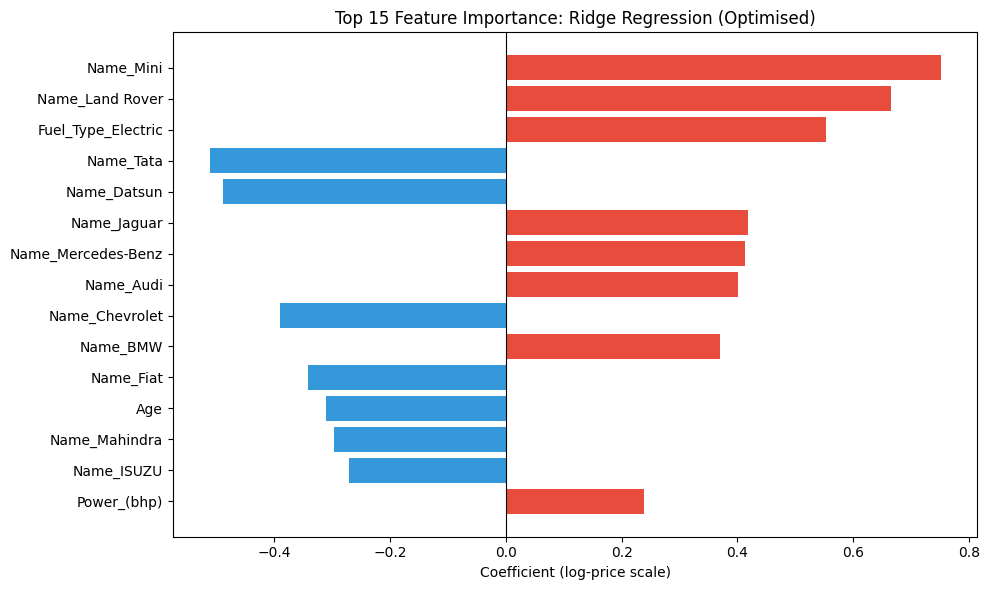

In [43]:
# Ridge Feature Importance
cat_features_ridge = (best_ridge.named_steps['preprocessor']
                      .transformers_[1][1]
                      .get_feature_names_out(categorical_cols))
all_features_ridge = numeric_cols + list(cat_features_ridge)

ridge_coefs = best_ridge.named_steps['regressor'].coef_
feat_df_ridge = (pd.DataFrame({'Feature': all_features_ridge, 'Coefficient': ridge_coefs})
                 .assign(Abs_Coef=lambda x: x['Coefficient'].abs())
                 .sort_values('Abs_Coef', ascending=False)
                 .head(15))

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in feat_df_ridge['Coefficient']]
plt.barh(feat_df_ridge['Feature'], feat_df_ridge['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (log-price scale)')
plt.title('Top 15 Feature Importance: Ridge Regression (Optimised)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

SHAP for Ridge regression


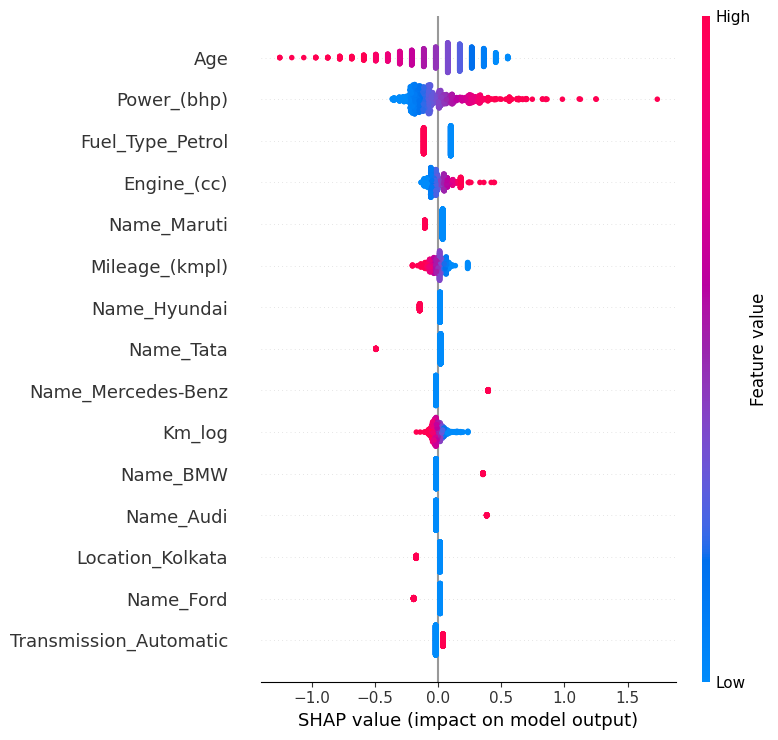

In [44]:

X_test_transformed_ridge = best_ridge.named_steps['preprocessor'].transform(X_test)

explainer_ridge = LinearExplainer(best_ridge.named_steps['regressor'],
                                   X_test_transformed_ridge)
shap_values_ridge = explainer_ridge.shap_values(X_test_transformed_ridge)

shap.summary_plot(shap_values_ridge, X_test_transformed_ridge,
                  feature_names=all_features_ridge, max_display=15)

# Hyperparameter Tunning/Optimisation: Random Forest

In [45]:

# Grid search with 5-fold CV to optimise Random Forest hyperparameters.

rf_param_grid = {
    'regressor__n_estimators':  [100, 200],
    'regressor__max_depth':     [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__max_features':  ['sqrt', 0.5]
}

rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_train, y_train)

best_rf = rf_grid_search.best_estimator_
print(f"\nBest parameters: {rf_grid_search.best_params_}")
print(f"Best CV R²     : {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'regressor__max_depth': None, 'regressor__max_features': 0.5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best CV R²     : 0.9409


# Evaluate Optimized Random Forest

In [46]:
y_pred_log_rf_opt    = best_rf.predict(X_test)
y_pred_actual_rf_opt = np.expm1(y_pred_log_rf_opt)

r2_rf_opt   = r2_score(y_test, y_pred_log_rf_opt)
mae_rf_opt  = mean_absolute_error(y_test_actual, y_pred_actual_rf_opt)
mape_rf_opt = mean_absolute_percentage_error(y_test_actual, y_pred_actual_rf_opt) * 100
rmse_rf_opt = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_rf_opt))

print("--- Random Forest (Optimised) ---")
print(f"R²          : {r2_rf_opt:.4f}")
print(f"MAE         : {mae_rf_opt:.2f} Lakhs")
print(f"MAPE (test) : {mape_rf_opt:.2f}%")
print(f"RMSE        : {rmse_rf_opt:.2f} Lakhs")

comparison_df.loc[len(comparison_df)] = {
    'Model': 'Random Forest (Optimised)', 'R² (test)': round(r2_rf_opt, 4),
    'MAE (lakhs)': round(mae_rf_opt, 2), 'MAPE (%)': round(mape_rf_opt, 2),
    'RMSE (lakhs)': round(rmse_rf_opt, 2),
    'CV R² Mean': round(rf_grid_search.best_score_, 4), 'CV R² Std': 0.0
}

print("\nUpdated Model Comparison:")
display(comparison_df.sort_values('R² (test)', ascending=False).reset_index(drop=True))

--- Random Forest (Optimised) ---
R²          : 0.9444
MAE         : 1.54 Lakhs
MAPE (test) : 15.43%
RMSE        : 4.80 Lakhs

Updated Model Comparison:


,Model,R² (test),MAE (lakhs),RMSE (lakhs),MAPE (%),CV R² Mean,CV R² Std
0,XGBoost,0.9462,1.49,4.13,15.54,0.9419,0.0123
1,Random Forest (Optimised),0.9444,1.54,4.80,15.43,0.9409,0.0000
2,Random Forest,0.9407,1.55,4.87,15.84,0.9361,0.0141
3,Ridge Regression,0.9224,1.76,4.56,19.66,0.9229,0.0110
4,Ridge Regression (Optimised),0.9224,1.76,4.56,19.66,0.9229,0.0000


# FEATURE IMPORTANCE: Random Forest

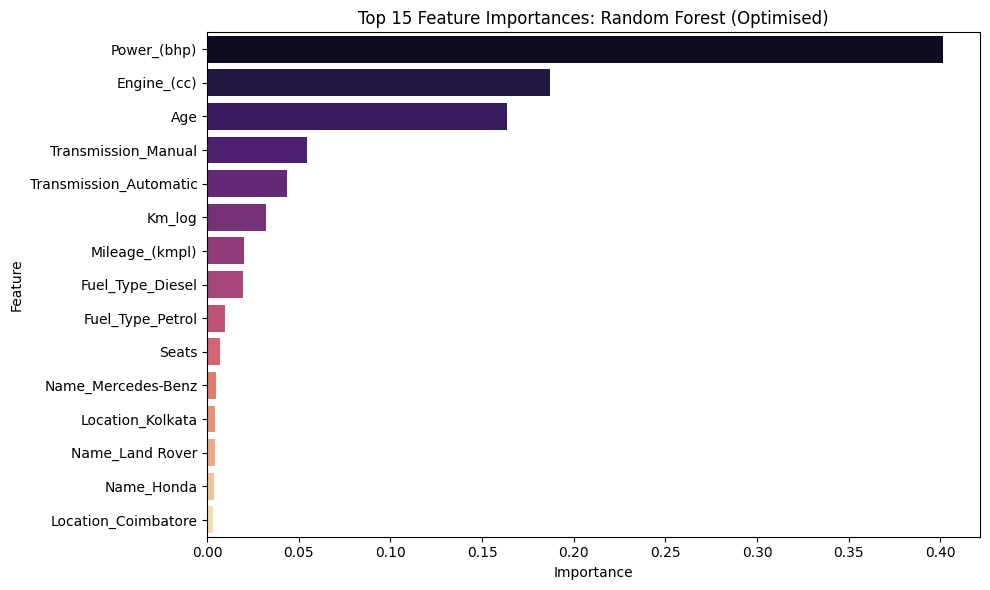

In [47]:
# RF Feature Importance for Optimised model
cat_features_rf = (best_rf.named_steps['preprocessor']
                   .transformers_[1][1]
                   .get_feature_names_out(categorical_cols))
all_features_rf = numeric_cols + list(cat_features_rf)

importances_rf = best_rf.named_steps['regressor'].feature_importances_
feat_df_rf = (pd.DataFrame({'Feature': all_features_rf, 'Importance': importances_rf})
              .sort_values('Importance', ascending=False)
              .head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df_rf, palette='magma')
plt.title('Top 15 Feature Importances: Random Forest (Optimised)')
plt.tight_layout()
plt.show()

## Hyperparameter Tunning/Optimisation: XGBoost (GridSearchCV)

Grid search with 5-fold cross-validation is used to optimise XGBoost hyperparameters.  
`n_jobs=-1` parallelises fitting across available CPU cores.

In [48]:
param_grid = {
    'regressor__n_estimators':  [100, 200],
    'regressor__max_depth':     [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__subsample':     [0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV R²     : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}
Best CV R²     : 0.9517


In [49]:
# Evaluate optimised XGBoost
y_pred_log_opt    = best_xgb.predict(X_test)
y_pred_actual_opt = np.expm1(y_pred_log_opt)

r2_opt   = r2_score(y_test, y_pred_log_opt)
mae_opt  = mean_absolute_error(y_test_actual, y_pred_actual_opt)
mape_opt = mean_absolute_percentage_error(y_test_actual, y_pred_actual_opt) * 100
rmse_opt = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_opt))

print("--- XGBoost (Optimised) ---")
print(f"R²          : {r2_opt:.4f}")
print(f"MAE         : {mae_opt:.2f} Lakhs")
print(f"MAPE (test) : {mape_opt:.2f}%")
print(f"RMSE        : {rmse_opt:.2f} Lakhs")

# Add to comparison
comparison_df.loc[len(comparison_df)] = {
    'Model': 'XGBoost (Optimised)', 'R² (test)': round(r2_opt, 4),
    'MAE (lakhs)': round(mae_opt, 2),'MAPE (%)': round(mape_opt, 2),
    'RMSE (lakhs)': round(rmse_opt, 2),
    'CV R² Mean': round(grid_search.best_score_, 4), 'CV R² Std': 0.0
}

print("\nUpdated Model Comparison:")
display(comparison_df.sort_values('R² (test)', ascending=False).reset_index(drop=True))

--- XGBoost (Optimised) ---
R²          : 0.9524
MAE         : 1.37 Lakhs
MAPE (test) : 13.69%
RMSE        : 4.69 Lakhs

Updated Model Comparison:


,Model,R² (test),MAE (lakhs),RMSE (lakhs),MAPE (%),CV R² Mean,CV R² Std
0,XGBoost (Optimised),0.9524,1.37,4.69,13.69,0.9517,0.0000
1,XGBoost,0.9462,1.49,4.13,15.54,0.9419,0.0123
2,Random Forest (Optimised),0.9444,1.54,4.80,15.43,0.9409,0.0000
3,Random Forest,0.9407,1.55,4.87,15.84,0.9361,0.0141
4,Ridge Regression,0.9224,1.76,4.56,19.66,0.9229,0.0110
5,Ridge Regression (Optimised),0.9224,1.76,4.56,19.66,0.9229,0.0000


## Feature Importance: Optimised XGBoost

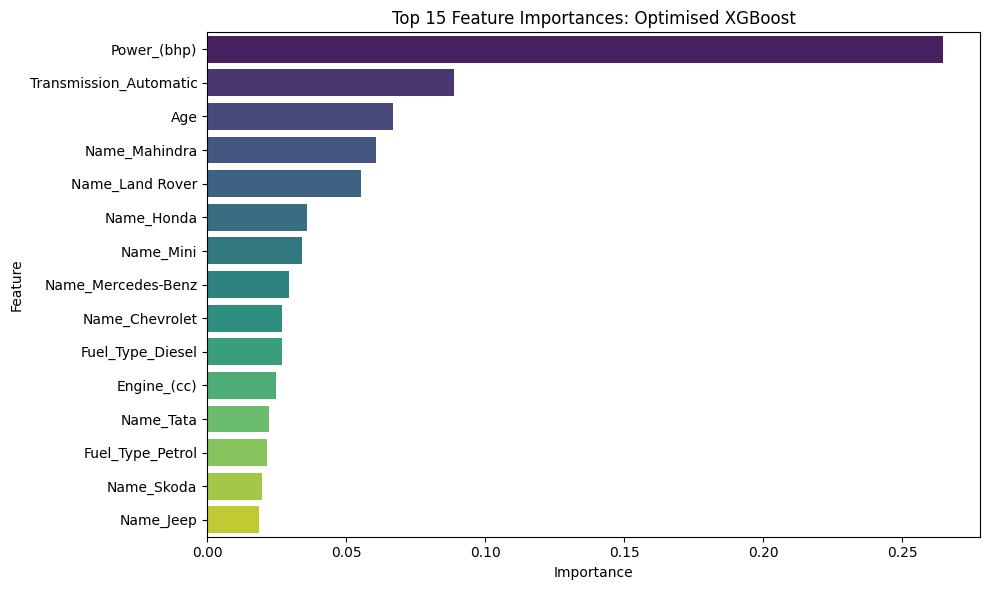

In [50]:

cat_features_xgb = (best_xgb.named_steps['preprocessor']
                    .transformers_[1][1]
                    .get_feature_names_out(categorical_cols))
all_features_xgb = numeric_cols + list(cat_features_xgb)

importances_xgb = best_xgb.named_steps['regressor'].feature_importances_
feat_df_xgb = (pd.DataFrame({'Feature': all_features_xgb, 'Importance': importances_xgb})
               .sort_values('Importance', ascending=False)
               .head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df_xgb, palette='viridis')
plt.title('Top 15 Feature Importances: Optimised XGBoost')
plt.tight_layout()
plt.show()

## Model Explainability: SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a theoretically grounded framework for interpreting model predictions at both global and individual levels (Lundberg & Lee, 2017).  
Unlike feature importance scores, SHAP shows both the **magnitude** and **direction** of each feature's effect on price.



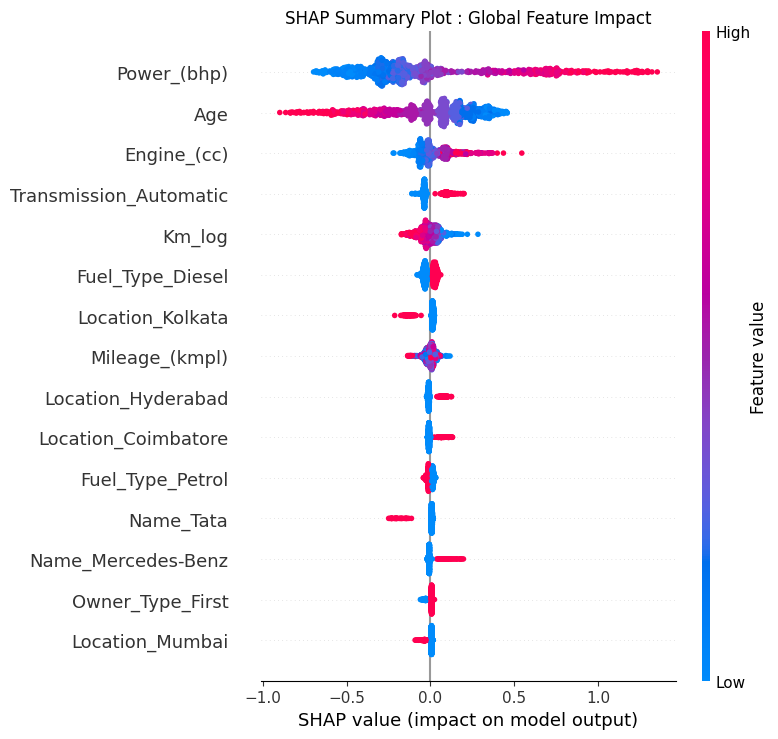

In [51]:
# Transform test data through the preprocessor step
X_test_transformed = best_xgb.named_steps['preprocessor'].transform(X_test)

# SHAP explainer using the fitted XGBoost regressor
explainer   = shap.Explainer(best_xgb.named_steps['regressor'])
shap_values = explainer(X_test_transformed)

# Global summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features_xgb, max_display=15, show=False)
plt.title('SHAP Summary Plot : Global Feature Impact')
plt.tight_layout()
plt.show()

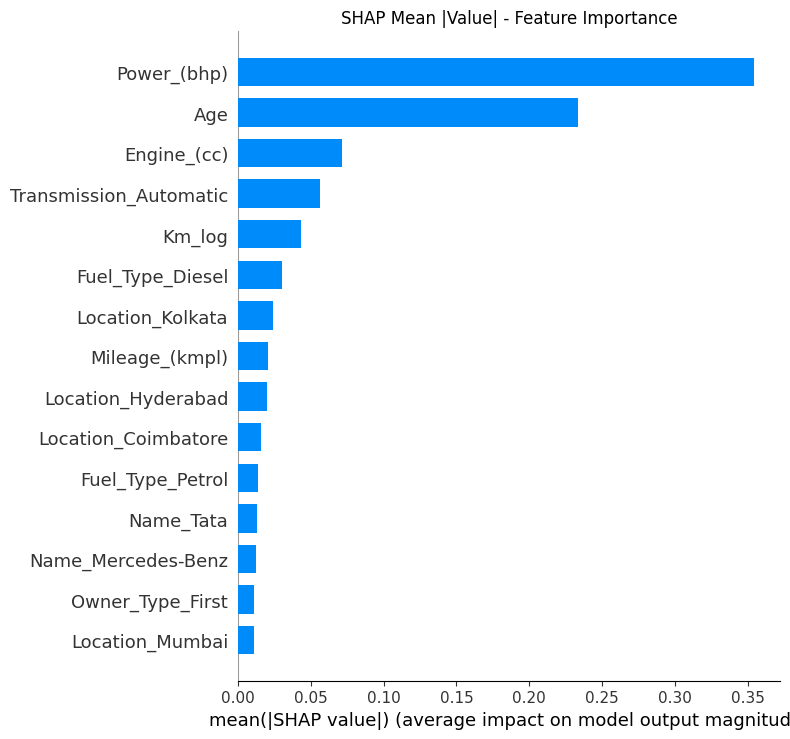

In [52]:
# SHAP bar plot for mean absolute impact
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features_xgb, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Mean |Value| - Feature Importance')
plt.tight_layout()
plt.show()

`Power_(bhp)` and `Age` dominate price predictions. Higher power significantly increases predicted price, while older cars see reduced predictions. `Engine_(cc)` and `Km_log` also contribute meaningfully, consistent with real-world depreciation patterns.

## Single-Sample Prediction Demo

A realistic example car is passed through the pipeline to demonstrate end-to-end prediction.

In [53]:
sample = pd.DataFrame([{
    'Name':           'Maruti',
    'Location':       'Mumbai',
    'Fuel_Type':      'Petrol',
    'Transmission':   'Manual',
    'Owner_Type':     'First',
    'Mileage_(kmpl)': 18.9,
    'Engine_(cc)':    1197.0,
    'Power_(bhp)':    82.0,
    'Seats':          5.0,
    'Age':            5,
    'Km_log':         np.log1p(45000)
}])

pred_log    = best_xgb.predict(sample)[0]
pred_actual = np.expm1(pred_log)
print(f"Sample car: 5-year-old Maruti Petrol Manual, 45,000 km, 82 bhp")
print(f"Predicted Price: ₹ {pred_actual:.2f} Lakhs")

Sample car: 5-year-old Maruti Petrol Manual, 45,000 km, 82 bhp
Predicted Price: ₹ 5.45 Lakhs
